**Neural network** 

**Neural network function**

784 pixels as inputs
10 numbers as outputs 
13,002 weight/biasis as Parameters
(we want to find weights and biases that minimizes the cost function)

**Cost function** 
13,002 weight/biases as input
Gradient vektor of cost function: decides how the weights should be adjusted 
1 cost as ouput (measure of how much our NN suck based on training example)


The loss function calculates the error for a single data point (sample), 
The cost function calculates the loss for the entire dataset. 
The cost of the NN is the sum of losses on individual training samples.


**Backpropagation**
Help us determine the gradient 




In [1]:
import numpy as np
import csv
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import cv2

In [2]:
import camera_tools as ct

In [3]:
#Calibrate the camera to detect green box, if you haven't done this calibration before
low_green, high_green = ct.colorpicker()
print(low_green)
print(high_green)

[ 0 74  0]
[255 114 255]


In [4]:
#Check whether the camera detects the green object properly
cam = ct.prepare_camera()
img = ct.capture_image(cam)
ct.show_camera(cam)

In [3]:
from Required_Tools.additions.fable_2_api.FableAPI.fable_init import api
api.setup(blocking=True)

PORT: /dev/cu.BeatsStudioBuds, NAME: n/a, HWID: n/a
PORT: /dev/cu.Bluetooth-Incoming-Port, NAME: n/a, HWID: n/a
PORT: /dev/cu.GimlisBox, NAME: n/a, HWID: n/a
PORT: /dev/cu.usbmodem14201, NAME: Fable Dongle 1.0, HWID: USB VID:PID=03EB:FABE LOCATION=20-2
Trying to connect /dev/cu.usbmodem14201 MAC implementation - tested!
dongle connect: True
Dongle...success
setup done


True

In [4]:
moduleids = api.discoverModules()
print("Module IDs: ", moduleids)
moduleID = moduleids[0]
print("Battery level:",api.getBattery(moduleID),"%")

discover modules!
b''
b'#\x08\x03\tA\xeeTXA '
['0x23', '0x8', '0x3', '0x9', '0x41', '0xee', '0x54', '0x58', '0x41', '0x20']
dt= 27.189970016479492 ms
got packet 238 True from TXA 
Runtime Created TXA 
b''
b''
b''
b''
b''
b''
found =  1
Module IDs:  ['TXA ']
Battery level: 86.4 %


In [11]:
moduleID

'TXA '

In [14]:
api.setPos(-90,0,moduleID)

0

In [7]:
#Create two files (if they were not already created) to collect data.
if (not os.path.exists("xycoords_2.csv")):
    f = open('xycoords_2.csv', 'w')
    with f:
        writer = csv.writer(f)
        writer.writerows([["X","Y"]])
    f.close()
if (not os.path.exists("angles_2.csv")):
    f = open('angles_2.csv','w')
    with f:
        writer = csv.writer(f)
        writer.writerows([["Y_angle"]])
    f.close()

In [16]:
moduleID

'TXA '

In [8]:
#we use the collectData function to collect the data for training.
    #we collect Y (angular) position of the end effector
    #we collect x,y coordinates of the end effector in the camera image
    #see the video final_project_guidance.mp4
def collectData(desired_angle_change):
    cam = ct.prepare_camera()
    ct.show_camera(cam)
    cam.release()
    cam = ct.prepare_camera()
    api.setPos(-90,90,moduleID)
    api.sleep(1.5)
    Y_angle_list = []
    XY_coordinates_list = []
    traversed_directions = 0
    current_direction = 0     # 1 is for clockwise, 0 is for anticlockwise
    traversedDirections = 0
    num_of_iterations = (int)(np.round(360/desired_angle_change,1))
    #Fable's Y arm traverse anticlockwise
    if current_direction == 0:
        for i in range(num_of_iterations):
            img = ct.capture_image(cam)
            x,y = ct.locate(img)
            currentRobotYAng = (int)(np.round(api.getPos(1,moduleID),1))
            Y_angle_list.append([currentRobotYAng])
            XY_coordinates_list.append([x,y])
            currentRobotYAng = currentRobotYAng - (desired_angle_change)
            api.setPos(-90,currentRobotYAng,moduleID)
            api.sleep(1.5)
            if np.abs(currentRobotYAng) > 90:
                current_direction = 1
                traversedDirections = traversedDirections + 1
                break
    #Fable's Y Arm traverses clockwise
    if current_direction == 1:
        for i in range(num_of_iterations):
            img = ct.capture_image(cam)
            x,y = ct.locate(img)
            currentRobotYAng = (int)(np.round(api.getPos(1,moduleID),1))
            Y_angle_list.append([currentRobotYAng])
            XY_coordinates_list.append([x,y])
            currentRobotYAng = currentRobotYAng + (desired_angle_change)
            api.setPos(-90,currentRobotYAng,moduleID)
            api.sleep(1.5)
            if np.abs(currentRobotYAng) > 90:
                current_direction = 0
                traversedDirections = traversedDirections + 1
                break
    if traversedDirections == 2:
        cam.release()
        #Save collected data to files
        y_angle_file_ptr = open('angles_2.csv', 'a+', newline ='')
        with y_angle_file_ptr:
            writer = csv.writer(y_angle_file_ptr)
            writer.writerows(Y_angle_list)
        y_angle_file_ptr.close()
        file_xycoords = open('xycoords_2.csv', 'a+', newline ='')
        with file_xycoords:
            writer = csv.writer(file_xycoords)
            writer.writerows(XY_coordinates_list)
        file_xycoords.close()
    return
    

In [9]:
cam = ct.prepare_camera()
ct.show_camera(cam)
cam.release()
cam = ct.prepare_camera()
api.setPos(-90,90,moduleID)
api.sleep(1.5)

In [9]:
#TODO: Call the CollectData() function with different values for 'desired_angle_change' argument and collect sufficient
#sufficient amout of data to angles_2.csv file and xycoords_2.csv file.
print("1")
collectData(1)
print("2")
collectData(2)
print("3")
collectData(3)
print("5")
collectData(5)
print("7")
collectData(7)
collectData(13)
collectData(15)
collectData(17)
collectData(19)
collectData(30)
collectData(50)
collectData(70)
collectData(80)
print("done")

1
2
3
5
7
done


In [9]:
#Use this function to calculate Y (angular) position errors 
# Y (angular) positions
def readAngleFilesAndCollectErrors(fileName):
    angleDataFrame = pd.read_csv(fileName)
    desired_column = angleDataFrame.columns[0]
    angle_error_list = []
    for i in range(1,len(angleDataFrame)):
        current_data_element = angleDataFrame[desired_column][i]
        previous_data_element = angleDataFrame[desired_column][i-1]
        #TODO???: Calculate the Y (angular) position error(say current_error) as the difference between 
        # the current Y (angular) position and previous Y (angular) position
        current_error = current_data_element - previous_data_element
        #print(current_data_element," ", previous_data_element, " ", current_error)
        angle_error_list = angle_error_list + [current_error]
    return angle_error_list

In [10]:
#Use this function to calculate errors between x and y coordinates
def readXYCoordsFilesAndCollectErrors(fileName):
    xyCoordsDataFrame = pd.read_csv(fileName)
    x_col_name = xyCoordsDataFrame.columns[0]
    y_col_name = xyCoordsDataFrame.columns[1]
    x_pos_error_list = []
    y_pos_error_list = []
    for i in range(1,len(xyCoordsDataFrame)):
        current_data_element_x = xyCoordsDataFrame[x_col_name][i]
        current_data_element_y = xyCoordsDataFrame[y_col_name][i]
        previous_data_element_x = xyCoordsDataFrame[x_col_name][i-1]
        previous_data_element_y = xyCoordsDataFrame[y_col_name][i-1]
        error_x_pos = current_data_element_x - previous_data_element_x 
        error_y_pos = current_data_element_y - previous_data_element_y
        x_pos_error_list = x_pos_error_list + [error_x_pos]
        y_pos_error_list = y_pos_error_list + [error_y_pos] 
    return [x_pos_error_list,y_pos_error_list]

In [11]:
#Read the provided files and load the calculated errors into to appropriate lists as follows
angle_error_list_1 = readAngleFilesAndCollectErrors("angles_1.csv")
x_pos_error_list_1,y_pos_error_list_1 = readXYCoordsFilesAndCollectErrors("xyCoords_1.csv")
#Read the files with the data dumped by you and load the calculated errors into appropriate lists.
angle_error_list_2 = readAngleFilesAndCollectErrors("angles_2.csv")
x_pos_error_list_2,y_pos_error_list_2 = readXYCoordsFilesAndCollectErrors("xyCoords_2.csv")

In [12]:
#merge both angle_error_list_1 and angle_error_list_2 to a single list and make it a numpy array called 'angle_error_array'
angle_error_array = np.array(angle_error_list_1 + angle_error_list_2 )
#merge both x_pos_error_list_1 and x_pos_error_list_2 to a single list and make it a numpy array called 'x_coord_error_array'
x_coord_error_array = np.array(x_pos_error_list_1 + x_pos_error_list_2)
#merge both y_pos_error_list_1 and y_pos_error_list_2 to a single list and make it a numpy array called 'y_coord_error_array'
y_coord_error_array = np.array(y_pos_error_list_1 + y_pos_error_list_2)

In [13]:
# Here we use 80% of the collected data  as the training set and 20% of the collected data as test set.
#TODO: Assign different propotions of the collected data set and test set and check how the test set error varies of the 
#Neural Network
data =  np.vstack((x_coord_error_array,y_coord_error_array)).T
target = np.vstack(angle_error_array)
data_input_tensor = torch.tensor(data.tolist()).float()
data_target_tensor = torch.tensor(target.tolist()).float()
data_with_target = torch.cat((data_input_tensor,data_target_tensor),1)
#TODO: what is the importance of using DataLoader utility function here?
loader= torch.utils.data.DataLoader(data_with_target,
                                     batch_size=data_with_target.size()[0], shuffle=True,
                                     num_workers=0)
#training set
train_set = []
#test set
test_set = []
for i in iter(loader):
    train_set_index = (int)(np.round(i.shape[0]*0.8))
    train_set = i[:train_set_index,:]
    test_set = i[train_set_index:,:]

In [14]:
print(train_set.shape)
print(test_set.shape)

torch.Size([742, 3])
torch.Size([185, 3])


In [6]:
#Defining Neural Network Model
class NN(torch.nn.Module):
    def __init__(self,n_feature,n_hidden1,n_hidden2,n_output):
        super(NN,self).__init__()
        self.hidden1 = torch.nn.Linear(n_feature,n_hidden1)
        #self.do1 = torch.nn.Dropout(0.15)
        #self.relu1 = torch.nn.LeakyReLU()
        #self.bn1 = torch.nn.BatchNorm1d(n_hidden1,affine=False)
        self.hidden2 = torch.nn.Linear(n_hidden1,n_hidden2)
        #self.bn2 = torch.nn.BatchNorm1d(n_hidden2,affine=False)
        #self.relu2 = torch.nn.LeakyReLU()
        #self.do2 = torch.nn.Dropout(0.1)
        self.predict = torch.nn.Linear(n_hidden2,n_output)
        
        
    def forward(self,x):
        x = self.hidden1(x)
        x = torch.sigmoid(x)
        #x = self.do1(x)
        x = self.hidden2(x)
        x = torch.sigmoid(x)
        #x = self.do2(x)
        x = self.predict(x)
        return x

In [12]:
#instantiate the Neural Network
#model = NN(n_feature=2,n_hidden1=17,n_hidden2=7, n_output=1)
model = NN(n_feature=2,n_hidden1=31,n_hidden2=13, n_output=1)

In [13]:
#Define loss function : 
# here we use Mean Square Error as the loss function
loss_func = torch.nn.MSELoss()

In [14]:
#Define the optimizer that should be used in training the Neural Network.
# Here 'lr' is the learning rate
optimizer = torch.optim.Adam(model.parameters(),lr=0.15)

In [26]:
train_set_inputs = train_set[:,:2]
#Calculate the mean value of the train_set_inputs. 
mean_of_train_input = torch.mean(train_set_inputs)
#standard deviation of the train set inputs.
std_of_the_train_input = torch.std(train_set_inputs,0)
#here we normalize the inputs of the neural network. What is the importance of that?
normalized_train_set_inputs = (train_set_inputs - mean_of_train_input)/std_of_the_train_input

In [16]:
#targets of the training set
train_set_targets = train_set[:,2][:,np.newaxis]

In [17]:
print(normalized_train_set_inputs.shape)
print(train_set_targets.shape)

torch.Size([742, 2])
torch.Size([742, 1])


In [18]:
#TODO: train the Neural network model by changing the hyper parameters such as learning rate, number of epochs, number of neurons in hidden layers of the neural network.
# What is the minimum mean square error that you can achieve as your neural network converges for the training set.
#  (you will be able to achive a MSE of less than 10 as the Neural network converges.)
num_epochs = 2200
losslist = []
for epoch in range(num_epochs):
    prediction = model(normalized_train_set_inputs) # Forward pass prediction. Saves intermediary values required for backwards pass
    loss = loss_func(prediction, train_set_targets) # Computes the loss for each example, using the loss function defined above
    optimizer.zero_grad() # Clears gradients from previous iteration
    loss.backward() # Backpropagation of errors through the network
    optimizer.step() # Updating weights
    # print("prediction =",prediction)
    # print("Loss: ", loss.detach().numpy())
    losslist.append(loss.detach().numpy())
    print(f"done epoch {epoch}")

print("Loss: ", loss.detach().numpy())

done epoch 0
done epoch 1
done epoch 2
done epoch 3
done epoch 4
done epoch 5
done epoch 6
done epoch 7
done epoch 8
done epoch 9
done epoch 10
done epoch 11
done epoch 12
done epoch 13
done epoch 14
done epoch 15
done epoch 16
done epoch 17
done epoch 18
done epoch 19
done epoch 20
done epoch 21
done epoch 22
done epoch 23
done epoch 24
done epoch 25
done epoch 26
done epoch 27
done epoch 28
done epoch 29
done epoch 30
done epoch 31
done epoch 32
done epoch 33
done epoch 34
done epoch 35
done epoch 36
done epoch 37
done epoch 38
done epoch 39
done epoch 40
done epoch 41
done epoch 42
done epoch 43
done epoch 44
done epoch 45
done epoch 46
done epoch 47
done epoch 48
done epoch 49
done epoch 50
done epoch 51
done epoch 52
done epoch 53
done epoch 54
done epoch 55
done epoch 56
done epoch 57
done epoch 58
done epoch 59
done epoch 60
done epoch 61
done epoch 62
done epoch 63
done epoch 64
done epoch 65
done epoch 66
done epoch 67
done epoch 68
done epoch 69
done epoch 70
done epoch 71
do

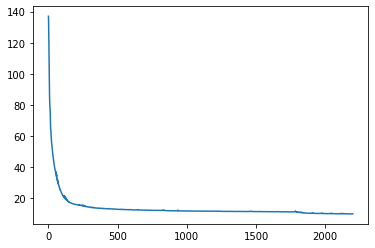

In [19]:
#plot the mean square error in each epoch/iteration
plt.plot(np.arange(len(losslist)),losslist)
plt.show()

In [28]:
#save the best neural network model you have obtained.
torch.save(model.state_dict(), 'best_nn_model.pth')

#Save the mean and standard deviation of the train set inputs because we need to use them at test time.

In [7]:
#reload the your best neural network model with saved parameters
model = NN(n_feature=2,n_hidden1=31,n_hidden2=13, n_output=1)
model.load_state_dict(torch.load('best_nn_model.pth'))

<All keys matched successfully>

In [15]:
#Extract inputs of the test_set
test_set_inputs = test_set[:,:2]
#Extract test set targets from the test_set
test_set_targets = test_set[:,2][:,np.newaxis]

In [16]:
mean_of_test_input = torch.mean(test_set_inputs)
#standard deviation of the test set inputs.
std_of_the_test_input = torch.std(test_set_inputs,0)

In [17]:
#Normalize test set inputs by using the mean and standard deviation of the inputs of the training set
normalized_test_set_inputs = (test_set_inputs - mean_of_test_input)/std_of_the_test_input

In [18]:
#feed the normalized test set inputs to the Neural Network model and obtain the prediction for the test set.
prediction_test = model(normalized_test_set_inputs)

In [19]:
print(prediction_test.shape)

torch.Size([185, 1])


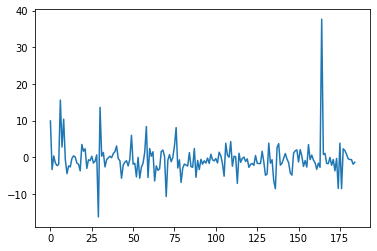

In [20]:
#plot the prediction error of the test set
test_set_prediction_error = prediction_test - test_set_targets
plt.plot(np.arange(len(test_set_prediction_error.tolist())),test_set_prediction_error.tolist())

In [ ]:
# In the example model trained with about 600 data, from a test set of 165 samples,
# 159 samples are predicted with prediction error less than 10.

In [ ]:
#TODO: Based on the prediction error of the test set, you can try to train the neural network again by changing the hyper parameters mentioned above.
# Also Try to add Dropout layers to the Neural network and check whether test prediction errors can be reduced further.

# Question 1: DETECTING THE OBJECT AT TESTING PHASE

In [25]:
def normalize_input(input):
    mean_of_input = torch.mean(input)
    #standard deviation of the test set inputs
    std_of_the_input = torch.std(input,0)
    return (input - mean_of_input)/std_of_the_input

In [22]:
#Here we implement the control loop which is having Neural Network as the controller.
#In this case we do not integrate CMAC to the control loop
def ControlLoopWithNNWithoutCMAC(target__x_coordinate,target__y_coordinate):
    
    number_of_iterations_for_convergence = 0
    
    #Intialize your best neural network model and load the saved paramemeters
    NN_model = NN(n_feature=2,n_hidden1=31,n_hidden2=13, n_output=1)
    NN_model.load_state_dict(torch.load('best_nn_model.pth'))
    
    #TODO: Obtain the x and y coodinates of the green box placed on the end effector of the robot
    cam = ct.prepare_camera()
    img = ct.capture_image(cam)
    x,y = ct.locate(img)
    robot_x_coord_in_image = x
    robot_y_coord_in_image = y
    #Here we loop for 50 iterations assuming that 
    # the controller should achieve the desired target within atmost 50 iterations
    for i in range(50):
        print(f"LOOP NUMBER {i}")
        x_coord_error = target__x_coordinate - robot_x_coord_in_image;
        y_coord_error = target__y_coordinate - robot_y_coord_in_image;
        #Here if the errors are less than twenty pixels we assume robot reaches the target. 
        # However you can choose any reasonable threshold value instead of 20.
        if (np.abs(x_coord_error) < 20 and np.abs(y_coord_error) < 20):
            print("number of iterations for convergence = ", number_of_iterations_for_convergence)
            break
        xy_input_nn_model = [float(x_coord_error),float(y_coord_error)]
        # print(xy_input_nn_model)
        xy_input_nn_model = torch.from_numpy(np.array(xy_input_nn_model))


        #TODO: normalize the input to the Neural network model using meaning and variance of the training set inputs.
        normalize_xy_input_nn_model = normalize_input(train_set_inputs)
        prediction_for_Y_pos_increment = NN_model(normalize_xy_input_nn_model)
         
        #TODO: Get the current Y (angular) position/angle of the robot. you can use the api.getPos function of fable
        robot_current_Y_pos = api.getPos(1, moduleID)   #(motorid, moduleID)
        #Next Y angular position of the robot will be robot_Y_pos + prediction_for_Y_pos_increment
        robot_next_Y_pos = robot_current_Y_pos + prediction_for_Y_pos_increment
        #Set the next position of the robot to (-90,robot_next_Y_pos) using the setPos function of the fable.
        api.setPos(-90,90,moduleID)
        api.sleep(1.5)
        number_of_iterations_for_convergence = number_of_iterations_for_convergence + 1
    return


In [30]:
#Detect the target object and obtain the coordinates of the object in the image
cam = ct.prepare_camera()
img = ct.capture_image(cam)
x,y = ct.locate(img)

target_x = x
target_y = y

In [43]:
target_x

577

In [44]:
target_y

444

In [31]:
#Call the control loop for a target which is detected. Record the number of iterations that the control loop spent for convergence.
ControlLoopWithNNWithoutCMAC(target_x,target_y)
#TODO: change your target location and try again. You may change the target 4-5 times and check how the control loop work.
#Record the number of iterations that the control loop spent for convergence.


LOOP NUMBER 0
LOOP NUMBER 1
LOOP NUMBER 2
LOOP NUMBER 3
LOOP NUMBER 4
LOOP NUMBER 5
LOOP NUMBER 6
LOOP NUMBER 7
LOOP NUMBER 8
LOOP NUMBER 9
LOOP NUMBER 10
LOOP NUMBER 11
LOOP NUMBER 12
LOOP NUMBER 13
LOOP NUMBER 14
LOOP NUMBER 15
LOOP NUMBER 16
LOOP NUMBER 17
LOOP NUMBER 18
LOOP NUMBER 19
LOOP NUMBER 20
LOOP NUMBER 21
LOOP NUMBER 22
LOOP NUMBER 23
LOOP NUMBER 24
LOOP NUMBER 25
LOOP NUMBER 26
LOOP NUMBER 27
LOOP NUMBER 28
LOOP NUMBER 29
LOOP NUMBER 30
LOOP NUMBER 31
LOOP NUMBER 32
LOOP NUMBER 33
LOOP NUMBER 34
LOOP NUMBER 35
LOOP NUMBER 36
LOOP NUMBER 37
LOOP NUMBER 38
LOOP NUMBER 39
LOOP NUMBER 40
LOOP NUMBER 41
LOOP NUMBER 42
LOOP NUMBER 43
LOOP NUMBER 44
LOOP NUMBER 45
LOOP NUMBER 46
LOOP NUMBER 47
LOOP NUMBER 48
LOOP NUMBER 49


In [ ]:
#Now integrate the CMAC to the previous control loop which had only the Neural Network. 
#The implementation of the CMAC can be found in code given for second week exercises.
#TODO: Implement the control loop with both neural network and CMAC. 
def ControlLoopWithBothNNandCMAC():
    return

In [ ]:
#TODO: Compare the number of iteration it takes for convergence in the control loop with 
# neural network only and with both CMAC and neural network.